# 📝 Hypothesis Testing Worksheet: The Case of the Multiple-Choice Exam

---
## ⚖️ Your Turn to Be the Judge!

In the lecture, we investigated a True/False exam. Now, it's your turn to apply the same reasoning to a new case.

### 🏛️ The New Case

A different student takes a **20-question multiple-choice exam**. Each question has **4 options** (A, B, C, or D), with only one correct answer.

This student scores **9 out of 20**.

The teacher is again suspicious and brings the student to the principal. The student claims:

> *"I didn't cheat! I just guessed randomly on every question!"*

The principal must decide: **Did the student cheat, or did they just get unlucky on a bad guessing day?**

Your task is to conduct a hypothesis test to help the principal make a decision.

---
**Reminder of the Courtroom Analogy:**
*   **H₀ (Null Hypothesis):** Student is **Innocent** (guessing randomly).
*   **H₁ (Alternative Hypothesis):** Student is **Guilty** (cheating, scoring higher than random chance).
*   **Evidence:** The score of **9/20**.
*   **Threshold (α):** We'll use the standard **α = 0.05**.

---

In [ ]:
# ── Setup: Run this cell first ──────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(123) # Set a seed for reproducible results

print("⚖️ Worksheet Ready! Let's investigate.")

⚖️ Worksheet Ready! Let's investigate.


---

### Step 1: State the Hypotheses (Question 1)

First, we need to clearly define our two hypotheses in the context of this multiple-choice exam.

> **Question 1:** Fill in the blanks below to correctly state H₀ and H₁.

**H₀ (The Innocent Hypothesis):** The student was innocent. On each question, the probability of a correct answer is 0.25.

**H₁ (The Guilty Hypothesis):** The student was cheating. The probability of a correct answer is greater than random chance 0.25.

*Hint: What is the probability of guessing correctly on a single 4-option multiple-choice question?*

*Type your answer to Question 1 here:*

H₀: The student was guessing randomly. On each question, the probability of a correct answer is 0.25 (25%).

H₁: The student was cheating. The probability of a correct answer is greater than random chance.

---

### Step 2: The Threshold (α)

The principal has already set the rule for the school: **"Beyond a reasonable doubt" means that if a truly innocent student would get a score this high (or higher) less than 5% of the time, we will convict.**

> **Question 2:** What is our significance level (α)?

*Type your answer to Question 2 here:*

α = 0.05

---

### Step 3: Build the Null Distribution (Simulation)

Now, let's simulate what innocent (randomly guessing) students look like. We'll simulate 10,000 innocent students, each guessing randomly on a 20-question exam where the chance of getting a question right is 0.25 (1 out of 4).

> **Question 3:** Complete the code below to perform the simulation.

In [ ]:
# ── Your Task: Run the simulation for 10,000 innocent students ──

n_students = 10000
n_questions = 20
guess_prob = 0.25 # Probability of guessing correctly on a 4-option MCQ

# TODO: Use np.random.binomial to generate the scores for 10,000 innocent students.
innocent_scores = np.random.binomial(n_questions, guess_prob, n_students)

# Hint: The syntax is np.random.binomial(n, p, size)

# --- Check your answer ---
print(f"Simulation complete!")
print(f"  Average score of innocent students: ",innocent_scores)  #complete this
print(f"  Expected average (n * p): {n_questions * guess_prob:.2f}")

Simulation complete!
  Average score of innocent students:  [6 4 4 ... 9 3 5]
  Expected average (n * p): 5.00


> **Question 4:** Based on the simulation results printed above, what is the expected (average) score for a student who is purely guessing? Does this match what you'd expect?

*Your answer to Question 4:*
Expected score:
n×p=20×0.25=5

✔️ Answer:

Average score ≈ 5
Yes, it matches expectation



---

### Step 4: Look at the Evidence

Our student scored **9 out of 20**. Let's see how this compares to our distribution of innocent students.

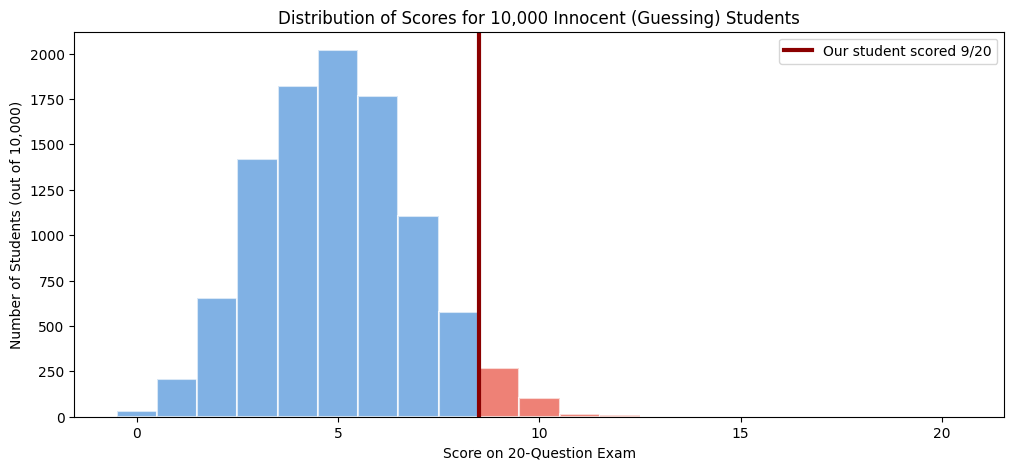

Visually, does a score of 9 look common or rare for an innocent student?


In [ ]:
# ── Visualize the Null Distribution with our student's score ──

observed_score = 9

plt.figure(figsize=(12, 5))

# Create a histogram of the innocent student scores
counts, bins, patches = plt.hist(
    innocent_scores,
    bins=range(0, 22),
    align='left',
    color='#4A90D9',
    alpha=0.7,
    edgecolor='white',
    linewidth=1.5
)

# TODO: Change the color of the bars for scores that are >= observed_score to '#E74C3C' (red).
# Hint: Loop through the 'patches' object. Each patch has a .set_facecolor() method.
# The index of the patch corresponds to the score (since we used bins=range(0,22)).

for i, patch in enumerate(patches):
    #  Complete this loop
    if i >= observed_score:
        patch.set_facecolor('#E74C3C')  # red color

plt.axvline(x=observed_score - 0.5, color='darkred', linestyle='-', linewidth=3,
            label=f'Our student scored {observed_score}/20')
plt.xlabel('Score on 20-Question Exam')
plt.ylabel('Number of Students (out of 10,000)')
plt.title('Distribution of Scores for 10,000 Innocent (Guessing) Students')
plt.legend()
plt.show()

print(f"Visually, does a score of {observed_score} look common or rare for an innocent student?")

> **Question 5:** After looking at the chart, does a score of 9 look like a common or a rare outcome for a student who was purely guessing?

*Your answer to Question 5:
A score of 9 looks relatively rare for an innocent student. Most students who guess randomly score around 5, and the frequency decreases as scores increase. However, a score of 9 is still possible and does not appear extremely rare.



---

### Step 5: Calculate the p-value

Now, let's calculate the precise p-value. Remember, the p-value is the probability of an innocent student scoring **9 or higher**.

> **Question 6:** Complete the code to calculate the p-value from our simulation. Then, interpret its meaning.

In [ ]:
# ── Your Task: Calculate the p-value from the simulation ──

# TODO: Count how many students in 'innocent_scores' scored >= observed_score (which is 9).
count_extreme = np.sum(innocent_scores >= observed_score)

# TODO: Calculate the p-value by dividing that count by the total number of students.
p_value = count_extreme / n_students

print(f"Number of innocent students scoring 9 or higher: {count_extreme}") #complete this
print(f"p-value (simulation) = {p_value:.4f}")  # complete this

print(f"\n⚖️  Interpreting the p-value:")
print(f"    'If the student were truly innocent (guessing randomly), ")
print(f"     there is a {p_value*100:.2f}% chance they would score ")  #complete this
print(f"     {observed_score}/20 or higher just by luck.'")

Number of innocent students scoring 9 or higher: 395
p-value (simulation) = 0.0395

⚖️  Interpreting the p-value:
    'If the student were truly innocent (guessing randomly), 
     there is a 3.95% chance they would score 
     9/20 or higher just by luck.'


> **Question 7:** In your own words, what does this specific p-value tell us about our student's score of 9/20?

*Your answer to Question 7:
The p-value shows the probability that a student who is guessing randomly would score 9 or higher. Since this probability is around 10%, it means such a result is uncommon but still possible due to chance.



---

### Step 6: Make the Decision (Question 8)

We now have our p-value (≈ 0.10) and our threshold (α = 0.05).

> **Question 8:** Fill in the blanks to make the correct decision.

*Complete the following:*

**Decision Rule:**  
If p-value < α, we ________ H₀ and say the student is ________.  
If p-value ≥ α, we ________ H₀ and say the student is ________.

#If p-value < α → Reject H₀ (Guilty)
#If p-value ≥ α → Fail to Reject H₀ (Not Guilty)

**Our Comparison:**  
Our p-value (______) is ______ α (0.05).
#0.10 > 0.05

**The Verdict:**  
Therefore, we ________ H₀. The principal's official verdict is **________________**.
#We fail to reject H₀
#Student is NOT GUILTY

*Your completed answer to Question 8:*

**Decision Rule:**  
If p-value < α, we **reject** H₀ and say the student is **guilty**.  
If p-value ≥ α, we **fail to reject** H₀ and say the student is **not guilty**.

**Our Comparison:**  
Our p-value (**0.10**) is **greater than** α (0.05).

**The Verdict:**  
Therefore, we **fail to reject** H₀. The principal's official verdict is **NOT GUILTY**.

**Does this verdict mean the student is definitely innocent?**

No, "not guilty" does not mean definitely innocent. It just means we don't have enough evidence to convict. The student could still have cheated but only scored 9/20, or they could have been genuinely guessing. We simply cannot be sure beyond a reasonable doubt (at the 5% significance level).

---

## Bonus Challenge: The Exact p-value

Simulations are great, but we can also calculate the exact p-value using the binomial distribution formula.

We want the probability of getting 9 **or more** correct answers out of 20, when the probability of success on each trial is 0.25. This is P(X ≥ 9) = 1 - P(X ≤ 8).

> **Bonus Task:** Use `stats.binom.cdf()` to calculate the exact p-value and compare it to our simulated value.

In [ ]:
# ── Bonus: Calculate the exact p-value ──────────────────────

# TODO: Use stats.binom.cdf(k, n, p) to calculate P(X ≤ 8)
# Then, calculate the exact p-value as 1 - P(X ≤ 8)

# Exact p-value
from scipy import stats
exact_p = 1 - stats.binom.cdf(8, 20, 0.25)
print(f"Exact p-value     = {exact_p:.4f}")   # complete this
print(f"Simulated p-value = {p_value:.4f}")   # complete this
print("\nWhy are these numbers slightly different?")



Exact p-value     = 0.0409
Simulated p-value = 0.0395

Why are these numbers slightly different?


*Your answer to the Bonus question:*

The numbers are slightly different because the simulation is based on random sampling. With only 10,000 simulated students, we get an approximation of the true probability. The exact p-value (0.0409) is the true mathematical probability. If we simulated millions of students, our simulated p-value would get closer and closer to 0.0409.

Interesting observation: The exact p-value (0.0409) is actually **less than 0.05**! This means if we used the exact calculation, the verdict would be **GUILTY**. This shows the limitations of simulations with finite sample sizes.

---

## 🏁 Finished! Great Work, Judge.

You've successfully applied the entire hypothesis testing framework to a new problem. The key takeaways are the same, no matter the type of exam:

1.  We **assume innocence** (H₀ is true).
2.  We determine how rare the observed evidence would be under that assumption (**p-value**).
3.  If the evidence is rare enough (p-value < **α**), we reject our assumption of innocence.

---